<a href="https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/rnn/001-simple-rnn-from-scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNN - Simple RNN from Scratch

In this notebook, we build a simple Recurrent Neural Network (RNN) from scratch using PyTorch, **without using high-level modules like `nn.RNN`**.  
We'll walk step by step through how an RNN operates internally by manually defining weight matrices, biases, and performing forward passes through the sequence.

We aim to teach our RNN to predict the next number in a simple linear sequence.  
For example, given a sequence:
```
1, 2, 3, 4, ..., n
```
The model should learn to predict:
```
2, 3, 4, 5, ..., n+1
```


## Setup

Let's define the configuration:

In [431]:
def setup_config():
    seed = 42 # @param {type:"integer"}
    n_epochs = 500 # @param {type:"integer"}
    learning_rate = 0.01 # @param {type:"number"}
    seq_length = 10 # @param {type:"integer"}
    input_size = 1 # @param {type:"integer"}
    hidden_size = 16 # @param {type:"integer"}
    output_size = 1 # @param {type:"integer"}
    target_seq_shifts = -1 # @param {type:"integer"}
    batch_size = 1 # @param {type:"integer"}
    nonlinearity = 'tanh' # @param ['tanh', 'relu']
    weight_init = 'xavier' # @param ['none', 'xavier', 'kaiming']
    max_grad_norm = 0.0 # @param {type:"number"}
    return {
        'seed' : seed,
        'n_epochs' : n_epochs,
        'learning_rate': learning_rate,
        'seq_length': seq_length,
        'input_size': input_size,
        'hidden_size': hidden_size,
        'output_size': output_size,
        'target_seq_shifts' : target_seq_shifts,
        'batch_size': batch_size,
        'nonlinearity': nonlinearity,
        'weight_init': weight_init,
        'max_grad_norm' : max_grad_norm
    }

CONFIG = setup_config()

Let's set the seed (for reproducibility):

In [432]:
torch.manual_seed(CONFIG['seed'])

Let's generate a sequence of numbers:

In [433]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def generate_sequence(seq_length = None):
    if seq_length is None: seq_length = CONFIG['seq_length']
    start = 1.0
    _start = torch.tensor([start])
    seq = _start + torch.arange(seq_length).float()
    return seq.unsqueeze(-1)

seq = generate_sequence()
seq.shape, seq

(torch.Size([10, 1]),
 tensor([[ 1.],
         [ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.]]))

And let's generate the corresponding sequence (the same sequence shifted by one position):


In [434]:
def get_target_seq(seq, shifts=None):
  if shifts is None: shifts = CONFIG['target_seq_shifts']
  return torch.roll(seq, shifts=shifts, dims=0)
target = get_target_seq(seq)
target.shape, target

(torch.Size([10, 1]),
 tensor([[ 2.],
         [ 3.],
         [ 4.],
         [ 5.],
         [ 6.],
         [ 7.],
         [ 8.],
         [ 9.],
         [10.],
         [ 1.]]))

Let's define the model parameters:


In [435]:
def build_model_params(input_size=None, hidden_size=None, weight_init=None, nonlinearity=None):
    if input_size is None: input_size = CONFIG['input_size']
    if hidden_size is None: hidden_size = CONFIG['hidden_size']
    if weight_init is None: weight_init = CONFIG['weight_init']
    if nonlinearity is None: nonlinearity = CONFIG['nonlinearity']

    Wxh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.1)
    Whh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)
    Why = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)
    bh = nn.Parameter(torch.zeros(1, hidden_size))
    by = nn.Parameter(torch.zeros(1, input_size))

    if weight_init == 'xavier':
        nn.init.xavier_uniform_(Wxh, gain=nn.init.calculate_gain(nonlinearity))
        nn.init.xavier_uniform_(Whh, gain=nn.init.calculate_gain(nonlinearity))
        nn.init.xavier_uniform_(Why, gain=nn.init.calculate_gain(nonlinearity))
    elif weight_init == 'kaiming':
        nn.init.kaiming_uniform_(Wxh, nonlinearity=nonlinearity)
        nn.init.kaiming_uniform_(Whh, nonlinearity=nonlinearity)
        nn.init.kaiming_uniform_(Why, nonlinearity=nonlinearity)

    return [Wxh, Whh, Why, bh, by]

model_params = build_model_params()
[Wxh, Whh, Why, bh, by] = model_params

Let's pluck the first value in the sequence to feed into the RNN:

In [436]:
x_t = seq[0]
x_t.shape, x_t

(torch.Size([1]), tensor([1.]))

Let's make sure the input has a batch size dimension (the first):

In [437]:
x_t = x_t.unsqueeze(0)
x_t.shape, x_t

(torch.Size([1, 1]), tensor([[1.]]))

Let's initialize the hidden state:

In [438]:
batch_size = CONFIG['batch_size']
hidden_size = CONFIG['hidden_size']
h = torch.zeros(batch_size, hidden_size)
h.shape, h

(torch.Size([1, 16]),
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))

Now let's simulate the forward pass of a single input (one item from the sequence). We'll:
1. Multiply the input by the input weight matrix
2. Add the result to the hidden state multiplied by the hidden state weight matrix
3. Add the hidden state bias
4. Apply a nonlinear activation function to the result


In [439]:
nonlinearity = CONFIG['nonlinearity']
if nonlinearity == 'tanh': activation_fn = torch.tanh
elif nonlinearity == 'relu': activation_fn = torch.relu
else: raise ValueError(f'Unknown activation: {nonlinearity}')

h = activation_fn(x_t @ Wxh + h @ Whh + bh)
h.shape, h

(torch.Size([1, 16]),
 tensor([[ 0.6805, -0.1541, -0.1123, -0.3835, -0.7134, -0.7459,  0.3522, -0.4957,
          -0.5625, -0.0771, -0.3183, -0.3098,  0.0318, -0.2070, -0.3283, -0.4415]],
        grad_fn=<TanhBackward0>))

With our new hidden state, we can calculate the output by multiplying it with the output weight matrix and adding the output bias.


In [440]:
y_t = h @ Why + by
y_t.shape, y_t

(torch.Size([1, 1]), tensor([[2.3644]], grad_fn=<AddBackward0>))

Processing the whole sequence follows a similar pattern. The key difference is that each calculation uses the hidden state from the previous step. This allows the network to maintain context from earlier inputs when processing new ones, which is the core mechanism of RNNs:


In [441]:
seq_length = CONFIG['seq_length']
outputs = []
for t in range(seq_length):
    x_t = seq[t].unsqueeze(0)
    h = activation_fn(x_t @ Wxh + h @ Whh + bh)
    y_t = h @ Why + by
    outputs.append(y_t)
outputs

[tensor([[1.9424]], grad_fn=<AddBackward0>),
 tensor([[3.2385]], grad_fn=<AddBackward0>),
 tensor([[2.3496]], grad_fn=<AddBackward0>),
 tensor([[3.7058]], grad_fn=<AddBackward0>),
 tensor([[3.5844]], grad_fn=<AddBackward0>),
 tensor([[4.8707]], grad_fn=<AddBackward0>),
 tensor([[4.2161]], grad_fn=<AddBackward0>),
 tensor([[4.9546]], grad_fn=<AddBackward0>),
 tensor([[4.1977]], grad_fn=<AddBackward0>),
 tensor([[4.6748]], grad_fn=<AddBackward0>)]

We've collected all our outputs in a list. Now we need to concatenate them into a tensor with shape `(20, 1)` to match our target sequence:


In [442]:
outputs = torch.cat(outputs, dim=0)
outputs.shape, outputs

(torch.Size([10, 1]),
 tensor([[1.9424],
         [3.2385],
         [2.3496],
         [3.7058],
         [3.5844],
         [4.8707],
         [4.2161],
         [4.9546],
         [4.1977],
         [4.6748]], grad_fn=<CatBackward0>))

We can now compare the predicted sequence to the target sequence and calculate the loss:

In [443]:
loss_fn = nn.MSELoss()
loss = loss_fn(outputs, target)
loss

tensor(9.2682, grad_fn=<MseLossBackward0>)

We now have everything we need to run a training loop:

Epoch [10/500], Loss: 4.7543
Epoch [20/500], Loss: 3.6372
Epoch [30/500], Loss: 2.7577
Epoch [40/500], Loss: 2.3222
Epoch [50/500], Loss: 1.9423
Epoch [60/500], Loss: 1.4442
Epoch [70/500], Loss: 1.0742
Epoch [80/500], Loss: 0.8036
Epoch [90/500], Loss: 0.6248
Epoch [100/500], Loss: 0.6857
Epoch [110/500], Loss: 1.0584
Epoch [120/500], Loss: 0.6032
Epoch [130/500], Loss: 0.5499
Epoch [140/500], Loss: 0.4027
Epoch [150/500], Loss: 0.3242
Epoch [160/500], Loss: 0.2657
Epoch [170/500], Loss: 0.2213
Epoch [180/500], Loss: 0.1872
Epoch [190/500], Loss: 0.1587
Epoch [200/500], Loss: 0.1342
Epoch [210/500], Loss: 0.1129
Epoch [220/500], Loss: 0.0942
Epoch [230/500], Loss: 0.0776
Epoch [240/500], Loss: 0.2669
Epoch [250/500], Loss: 1.1944
Epoch [260/500], Loss: 0.7225
Epoch [270/500], Loss: 0.2912
Epoch [280/500], Loss: 0.1904
Epoch [290/500], Loss: 0.1429
Epoch [300/500], Loss: 0.1055
Epoch [310/500], Loss: 0.0802
Epoch [320/500], Loss: 0.0617
Epoch [330/500], Loss: 0.0481
Epoch [340/500], Lo

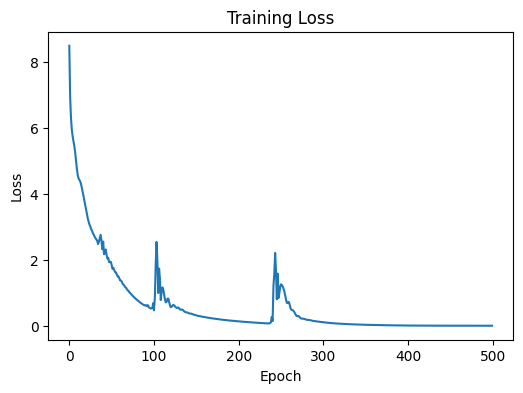

In [444]:
# Hyperparameters
n_epochs = CONFIG['n_epochs']
learning_rate = CONFIG['learning_rate']

loss_fn = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model_params, lr=learning_rate)

loss_history = []

# Initialize gradient tracking
gradients_over_time = {
    'Wxh': [],
    'Whh': [],
    'Why': [],
    'hidden_state_norms': []
}

for epoch in range(n_epochs):
    seq = generate_sequence()
    target = get_target_seq(seq)

    # Initialize hidden state
    h = torch.zeros(batch_size, hidden_size)

    outputs = []
    hidden_states = []  # For visualization

    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)

        # Retain gradients of hidden state for each time step
        h.retain_grad()

        y_t = h @ Why + by

        outputs.append(y_t)
        hidden_states.append(h)

    outputs = torch.cat(outputs, dim=0)

    loss = loss_fn(outputs, target)

    optimizer.zero_grad()
    loss.backward()

    max_grad_norm = CONFIG['max_grad_norm']
    if max_grad_norm: torch.nn.utils.clip_grad_norm_(model_params, max_norm=max_grad_norm)

    # Track gradient norms after backward
    gradients_over_time['Wxh'].append(Wxh.grad.norm().item())
    gradients_over_time['Whh'].append(Whh.grad.norm().item())
    gradients_over_time['Why'].append(Why.grad.norm().item())

    # Track hidden state gradient norms per time step
    hidden_state_grad_norms = [h.grad.norm().item() for h in hidden_states]
    gradients_over_time['hidden_state_norms'].append(hidden_state_grad_norms)

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

# Plot loss curve
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

The loss has stagnated, indicating that the model has finished learning, let's test its predictions:

In [445]:
outputs=[]
with torch.no_grad():
    seq = generate_sequence()
    target = get_target_seq(seq)
    h = torch.zeros(batch_size, hidden_size)
    predictions = []
    hidden_states = []
    for t in range(seq_length):
        x_t = seq[t].unsqueeze(0)  # shape: (1, input_size)
        h = activation_fn(x_t @ Wxh + h @ Whh + bh)
        y_t = h @ Why + by
        predictions.append(y_t.item())
        hidden_states.append(h.numpy())
[round(x) for x in predictions], target.view(-1).int().tolist()

([2, 3, 4, 5, 6, 7, 8, 9, 10, 1], [2, 3, 4, 5, 6, 7, 8, 9, 10, 1])

The model has failed to learn the sequence correctly. It begins with accurate predictions but deteriorates further along the sequence. Let's analyze how the hidden states behave throughout the sequence to understand why:


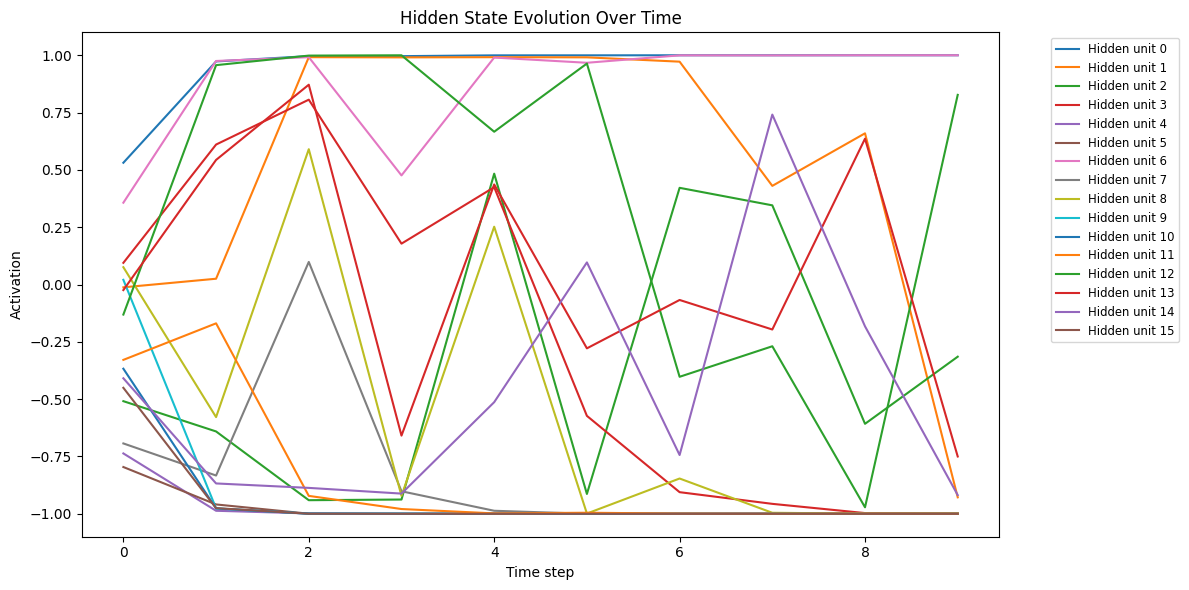

In [446]:
# Visualize hidden state evolution
hidden_states = torch.tensor(hidden_states).squeeze(1).numpy()  # shape: (seq_length, hidden_size)

plt.figure(figsize=(12, 6))
for i in range(hidden_size): plt.plot(hidden_states[:, i], label=f'Hidden unit {i}')
plt.title('Hidden State Evolution Over Time')
plt.xlabel('Time step')
plt.ylabel('Activation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1, fontsize='small')
plt.tight_layout()
plt.show()

The graph above reveals that hidden states are converging to the extremes of the tanh function. At these extremes, the function has a flat surface where gradients approach zero, leading to the vanishing gradient problem. This means:

1. No meaningful learning occurs at these points
2. We cannot effectively backpropagate the loss through the entire calculation chain
3. The model fails to make the necessary parameter adjustments to minimize the loss


Here is another way to visualize the same phenomenon:

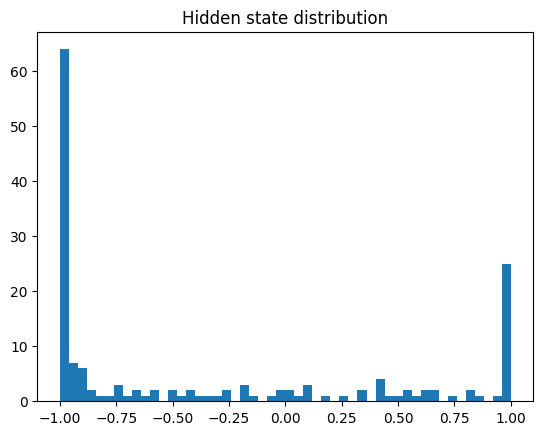

In [447]:
plt.hist(hidden_states.flatten(), bins=50)
plt.title('Hidden state distribution')
plt.show()

Let's plot the gradients of these hidden states across time steps:

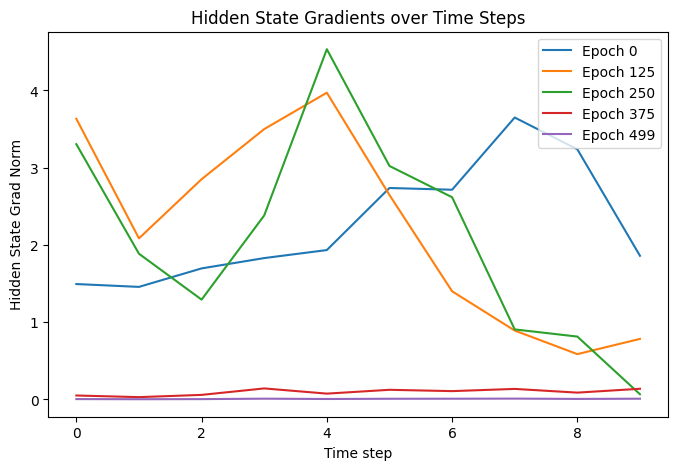

In [448]:
# Dynamically select epochs to plot
total_epochs = len(gradients_over_time['hidden_state_norms'])

# Let's pick evenly spaced epochs: start, early, mid, late, end
epochs_to_plot = [
    0,
    max(1, total_epochs // 4),
    max(1, total_epochs // 2),
    max(1, (3 * total_epochs) // 4),
    total_epochs - 1
]

plt.figure(figsize=(8, 5))
for epoch in epochs_to_plot:
    grad_norms = gradients_over_time['hidden_state_norms'][epoch]
    plt.plot(grad_norms, label=f'Epoch {epoch}')
plt.xlabel('Time step')
plt.ylabel('Hidden State Grad Norm')
plt.title('Hidden State Gradients over Time Steps')
plt.legend()
plt.show()

Notice how the hidden state gradient magnitudes diminish the further back we go in the sequence - a clear visualization of the vanishing gradient problem that's preventing our model from learning long-range dependencies.


Now let's plot the gradient norms of the weight parameters across epochs:

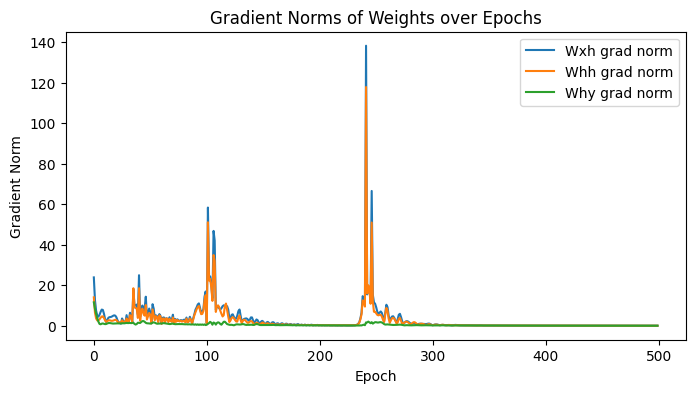

In [449]:
plt.figure(figsize=(8, 4))
plt.plot(gradients_over_time['Wxh'], label='Wxh grad norm')
plt.plot(gradients_over_time['Whh'], label='Whh grad norm')
plt.plot(gradients_over_time['Why'], label='Why grad norm')
plt.xlabel('Epoch')
plt.ylabel('Gradient Norm')
plt.title('Gradient Norms of Weights over Epochs')
plt.legend()
plt.show()

## Next Steps

I suggest running this notebook again with the following modifications (test each one separately before combining them):

**1. Enable proper weight initialization**
- The current parameter initialization may contribute to early tanh saturation
- Use Xavier initialization for tanh/sigmoid activations
- Use Kaiming initialization for ReLU activations
- This helps constrain initial activations and improve learning

**2. Enable gradient clipping**
- While we're facing vanishing gradients, the occasional gradient explosions visible in our graphs may be problematic
- Set `max_grad_norm` to `1.0` to rescale gradients to a smaller range
- This may help keep values within the responsive region of the tanh activation
- Note: When limiting gradient size, you may need to increase training epochs (since updates become smaller)

**3. Try ReLU as the activation function**
- Unlike tanh, ReLU doesn't constrain values to [-1, 1]
- For our positive-value sequence, this should prevent gradient collapse
- ReLU allows gradients to flow properly through the network
- Note: ReLU can face similar issues (dying ReLUs) with negative values, where activations become zero
